<a href="https://colab.research.google.com/github/timuriz/ObjectSegmentationMarsWS25/blob/main/M_eval_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install wandb -qq
!pip install -q wandb

In [29]:
import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.models.segmentation as tvseg
from torch.utils.data import Dataset, DataLoader
import torchvision.models.segmentation as models

import wandb

from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

os.environ['WANDB_API_KEY'] = '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'
wandb.login()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


NUM_CLASSES_WITH_IGNORE = 4   # IDs: 0..4
IGNORE_INDEX = 0

ID_TO_NAME = {
    0: "ignore/background",
    1: "sand",
    2: "soil",
    3: "bedrock",
}

CLASS_NAMES_ALL = [ID_TO_NAME[i] for i in range(NUM_CLASSES_WITH_IGNORE)]
CLASS_NAMES = [ID_TO_NAME[i] for i in range(1, NUM_CLASSES_WITH_IGNORE)]  # for reporting metrics later


IMG_SIZE = 768  # must match training/eval preprocessing

IMAGES_DIR = "/content/drive/MyDrive/ML course/images_val_last_clean_dataset"
MASKS_DIR  = "/content/drive/MyDrive/ML course/masks_val_last_clean_dataset"

CHECKPOINT_PATH = "/content/drive/MyDrive/ML course/checkpoints_best_new.pt"
BATCH_SIZE = 2

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


#Initialize W&B

In [30]:
wandb.init(
    project="Mars_Segmentation_Project",
    name="evaluation-final-test",
    config={
        "num_classes_with_ignore": NUM_CLASSES_WITH_IGNORE,
        "ignore_index": IGNORE_INDEX,
        "classes": {
            1: "sand",
            2: "soil",
            3: "bedrock",
        },
        "image_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
    }
)

mIoU,▁
mean_class_acc,▁
mean_dice,▁
pixel_acc,▁
mIoU,0.71664
mean_class_acc,0.8298
mean_dice,0.82998
pixel_acc,0.89806


#LOAD THE MODEL + CHECKPOINT


In [31]:
def create_model(num_classes):
    model = tvseg.deeplabv3_resnet50(weights=None, weights_backbone=None)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    return model

model = create_model(NUM_CLASSES_WITH_IGNORE).to(DEVICE)
model.eval()
print("Model ready.")

Model ready.


In [32]:
def load_checkpoint(model, ckpt_path: str, device: str):
    ckpt = torch.load(ckpt_path, map_location=device)

    state = ckpt["model_state_dict"]

    model.load_state_dict(state, strict=False)

    print("Checkpoint loaded.")

load_checkpoint(model, CHECKPOINT_PATH, DEVICE)

Checkpoint loaded.


#Data transform

In [33]:
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
    ToTensorV2()
])

class EvalSegDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.names = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".png")])
        self.transform = transform

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        img_path = os.path.join(self.images_dir, name)
        mask_path = os.path.join(self.masks_dir, name)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path)).astype(np.int64)  # IDs 0..3

        out = self.transform(image=image, mask=mask)
        return out["image"].float(), out["mask"].long(), name

eval_ds = EvalSegDataset(IMAGES_DIR, MASKS_DIR, val_transform)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Eval dataset size:", len(eval_ds))

Eval dataset size: 158


#EVAl metrics

In [34]:
import numpy as np
import torch

def cm_update(cm, gt, pred, num_classes, ignore_index=0, include_ignore=False):
    """
    cm: numpy array (K,K)
    gt, pred: torch tensors (B,H,W) with class IDs
    """
    gt = gt.reshape(-1)
    pred = pred.reshape(-1)

    if include_ignore:
        valid = torch.ones_like(gt, dtype=torch.bool)
    else:
        valid = (gt != ignore_index)

    gt = gt[valid]
    pred = pred[valid]

    k = num_classes
    idx = gt * k + pred
    bc = torch.bincount(idx, minlength=k*k).detach().cpu().numpy()
    cm += bc.reshape(k, k)
    return cm

In [35]:
def get_cm_percentage_matrix(cm):
    cm_normalized = cm.astype(np.float64)
    row_sums = cm_normalized.sum(axis=1)

    # Avoid division by zero for rows with no ground truth pixels
    row_sums[row_sums == 0] = 1

    cm_percentage = (cm_normalized / row_sums[:, np.newaxis]) * 100
    return cm_percentage

In [36]:
def metrics_from_cm(cm, class_ids):
    """
    cm: numpy array (K,K)
    class_ids: list like [1,2,3]
    """
    cm = cm.astype(np.float64)

    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    iou = {}
    dice = {}
    recall = {}  # (mean class accuracy style)

    for c in class_ids:
        denom_iou = tp[c] + fp[c] + fn[c]
        iou[c] = np.nan if denom_iou == 0 else tp[c] / denom_iou

        denom_dice = 2*tp[c] + fp[c] + fn[c]
        dice[c] = np.nan if denom_dice == 0 else (2*tp[c]) / denom_dice

        denom_rec = tp[c] + fn[c]
        recall[c] = np.nan if denom_rec == 0 else tp[c] / denom_rec

    miou = float(np.nanmean(list(iou.values())))
    mean_dice = float(np.nanmean(list(dice.values())))
    mean_class_acc = float(np.nanmean(list(recall.values())))

    # Pixel accuracy over evaluated classes+pixels is simply trace / sum
    pixel_acc = float(tp.sum() / cm.sum()) if cm.sum() > 0 else float("nan")

    return {
        "miou": miou,
        "iou_per_class": iou,
        "mean_dice": mean_dice,
        "dice_per_class": dice,
        "pixel_acc": pixel_acc,
        "mean_class_acc": mean_class_acc,
    }

In [37]:
def batch_error_rate(preds: torch.Tensor, masks: torch.Tensor, ignore_index: int = 0):
    valid = (masks != ignore_index)
    wrong = (preds != masks) & valid

    wrong_pixels = wrong.flatten(1).sum(dim=1).detach().cpu().numpy()
    valid_pixels = valid.flatten(1).sum(dim=1).detach().cpu().numpy()

    return wrong_pixels / np.maximum(valid_pixels, 1)

#Evaluation

In [38]:
CLASS_IDS = list(range(1, NUM_CLASSES_WITH_IGNORE))
IGNORE_INDEX = 0

cm_full    = np.zeros((NUM_CLASSES_WITH_IGNORE, NUM_CLASSES_WITH_IGNORE), dtype=np.int64)  # includes gt=0
worst_records = []   # list of tuples: (error_rate, global_index, name)
global_idx = 0

model.eval()
with torch.no_grad():
    for images, masks, names in eval_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        preds = torch.argmax(model(images)["out"], dim=1)
        rates = batch_error_rate(preds, masks, ignore_index=IGNORE_INDEX)  # (B,)

        for i, name in enumerate(names):
            worst_records.append((float(rates[i]), global_idx, name))
            global_idx += 1
        cm_full    = cm_update(cm_full, masks, preds, NUM_CLASSES_WITH_IGNORE, IGNORE_INDEX, include_ignore=True)

In [39]:
N = 10
worst_records.sort(reverse=True)
worst_records_final = worst_records[:N]+worst_records[len(worst_records) - N:]
print("Worst samples:")
for r, idx, name in worst_records_final:
    print(f"{name} | idx={idx} | error_rate={r:.4f}")
print("done")

Worst samples:
0786.png | idx=12 | error_rate=0.9840
0796.png | idx=22 | error_rate=0.9806
0793.png | idx=19 | error_rate=0.8225
0855.png | idx=81 | error_rate=0.7995
0788.png | idx=14 | error_rate=0.7489
0900.png | idx=126 | error_rate=0.6582
0803.png | idx=29 | error_rate=0.5719
0846.png | idx=72 | error_rate=0.4539
0901.png | idx=127 | error_rate=0.4462
0881.png | idx=107 | error_rate=0.4108
0821.png | idx=47 | error_rate=0.0004
0886.png | idx=112 | error_rate=0.0003
0888.png | idx=114 | error_rate=0.0003
0811.png | idx=37 | error_rate=0.0002
0845.png | idx=71 | error_rate=0.0002
0838.png | idx=64 | error_rate=0.0001
0836.png | idx=62 | error_rate=0.0001
0876.png | idx=102 | error_rate=0.0001
0873.png | idx=99 | error_rate=0.0000
0809.png | idx=35 | error_rate=0.0000
done


In [40]:
metrics = metrics_from_cm(cm_full, CLASS_IDS)
print("mIoU:", metrics["miou"])
print(cm_full)
print()
print(get_cm_percentage_matrix(cm_full))

mIoU: 0.716640983834404
[[24278241   110842   332744   373227]
 [   21157  5049674  1109997  1053933]
 [  127388  1494716 31259028  2609348]
 [   73794   136033  2057124 23104946]]

[[96.74512356  0.44168863  1.32593458  1.48725323]
 [ 0.29243537 69.79738515 15.34255244 14.56762704]
 [ 0.35893569  4.21159703 88.07721958  7.3522477 ]
 [ 0.29084936  0.5361562   8.10788409 91.06511035]]


In [41]:
wandb.log({
    "mIoU": metrics['miou'],
    "Iou_per_class": metrics['iou_per_class'],
    "mean_dice": metrics['mean_dice'],
    "dice_per_class": metrics['dice_per_class'],
    "pixel_acc": metrics['pixel_acc'],
    "mean_class_acc": metrics['mean_class_acc'],
    "cm_matrix": get_cm_percentage_matrix(cm_full)
    })

#VISUALISATION(10 worst and 10 best)



[0] 0786.png | idx=12 | error_rate=0.9840 | unique IDs (GT): [0, 3]


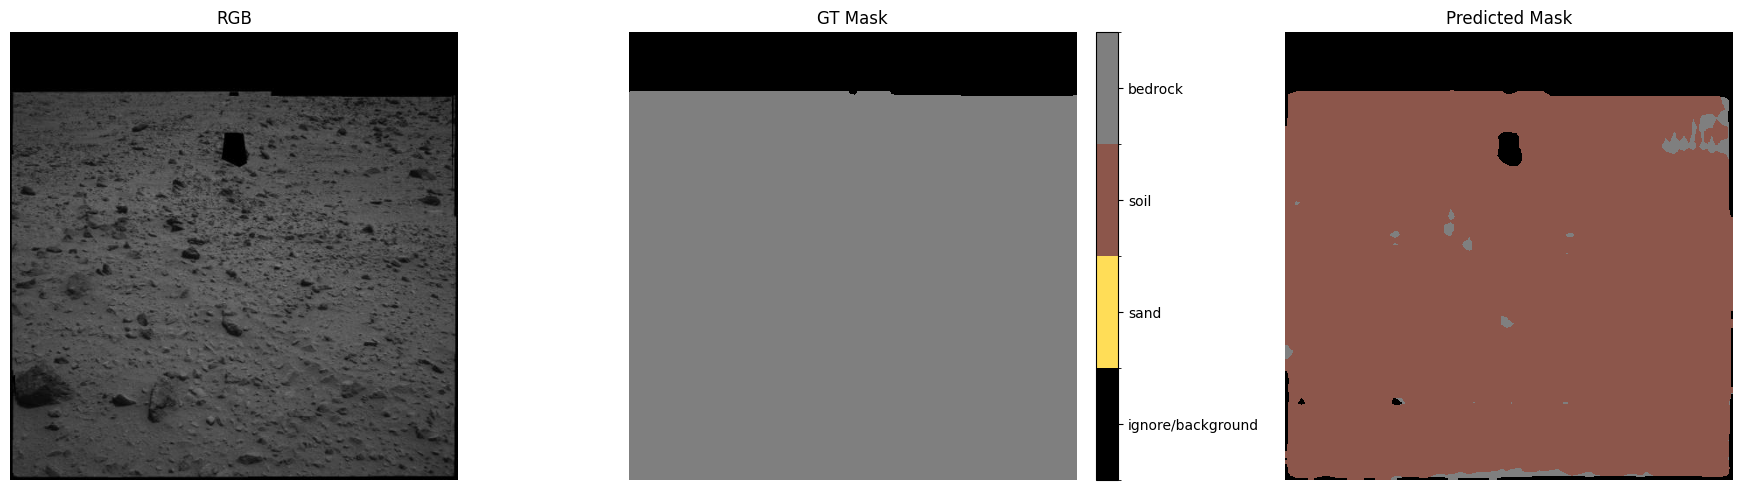


[1] 0796.png | idx=22 | error_rate=0.9806 | unique IDs (GT): [0, 2]


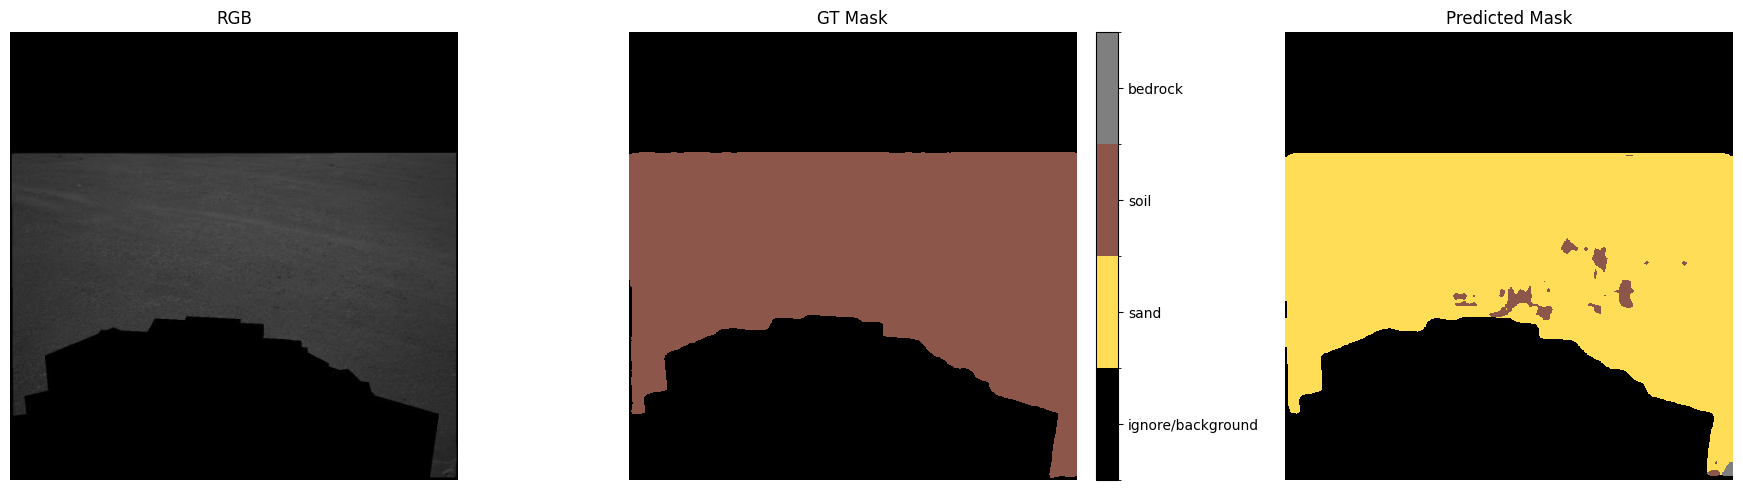


[2] 0793.png | idx=19 | error_rate=0.8225 | unique IDs (GT): [0, 1, 2]


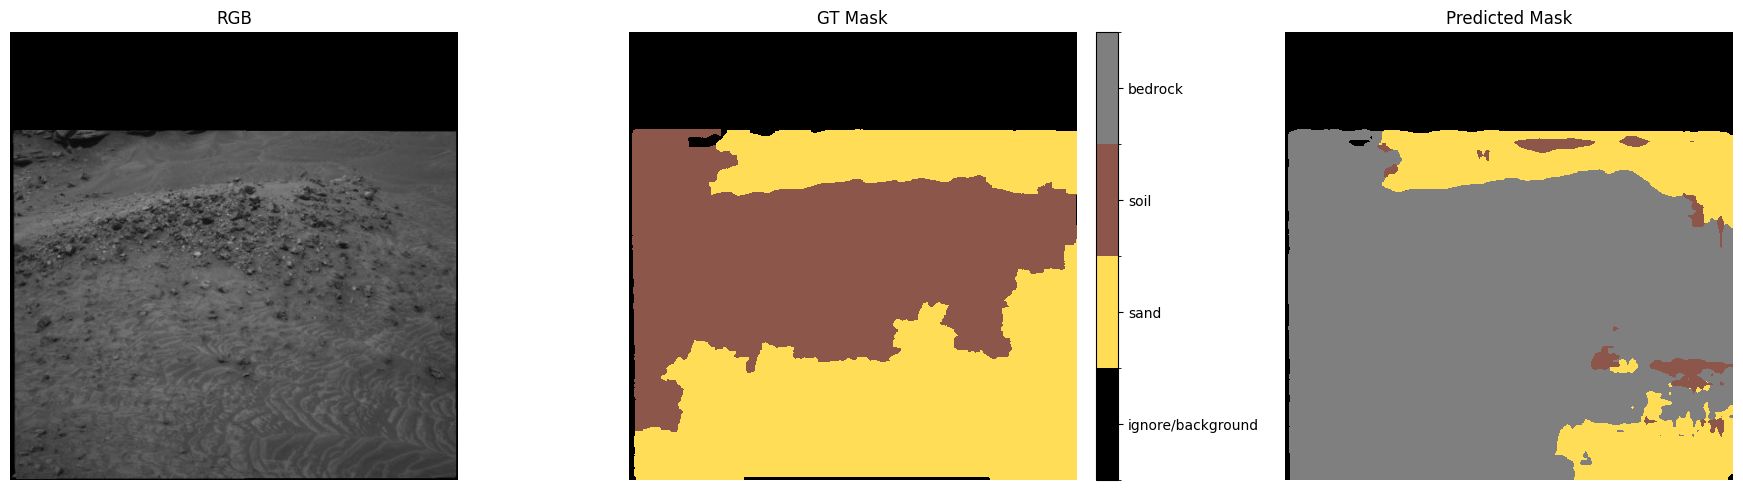


[3] 0855.png | idx=81 | error_rate=0.7995 | unique IDs (GT): [0, 1, 2, 3]


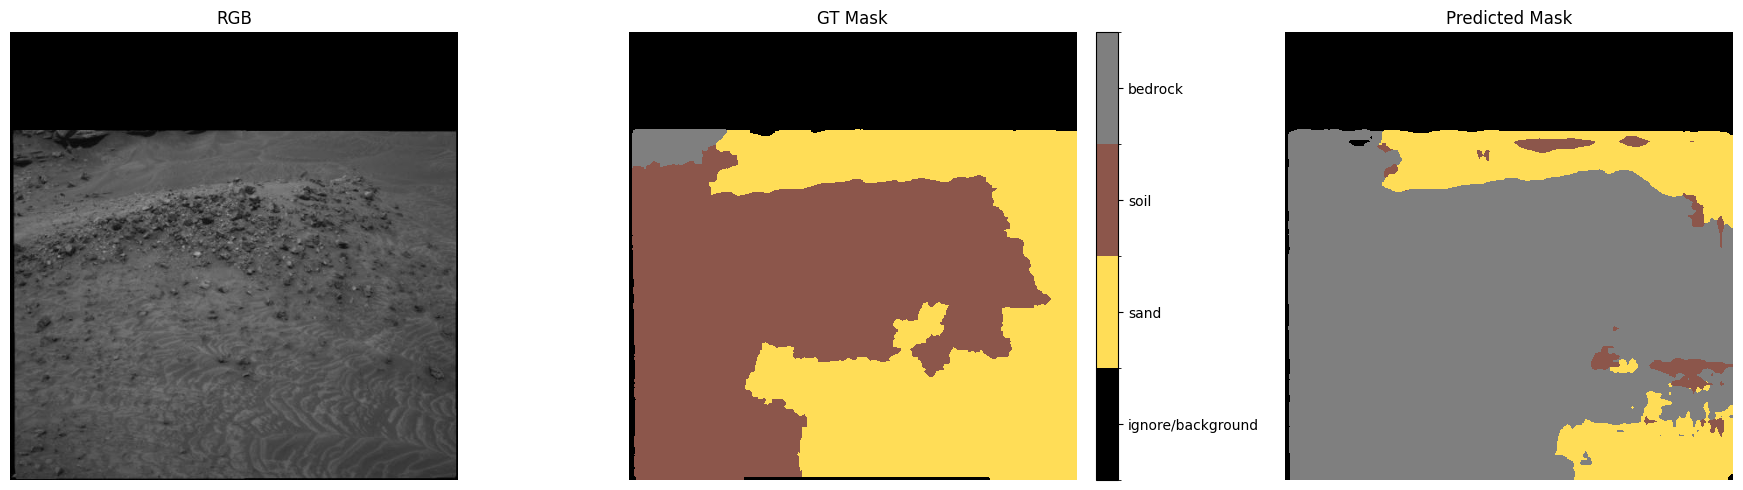


[4] 0788.png | idx=14 | error_rate=0.7489 | unique IDs (GT): [0, 1, 2, 3]


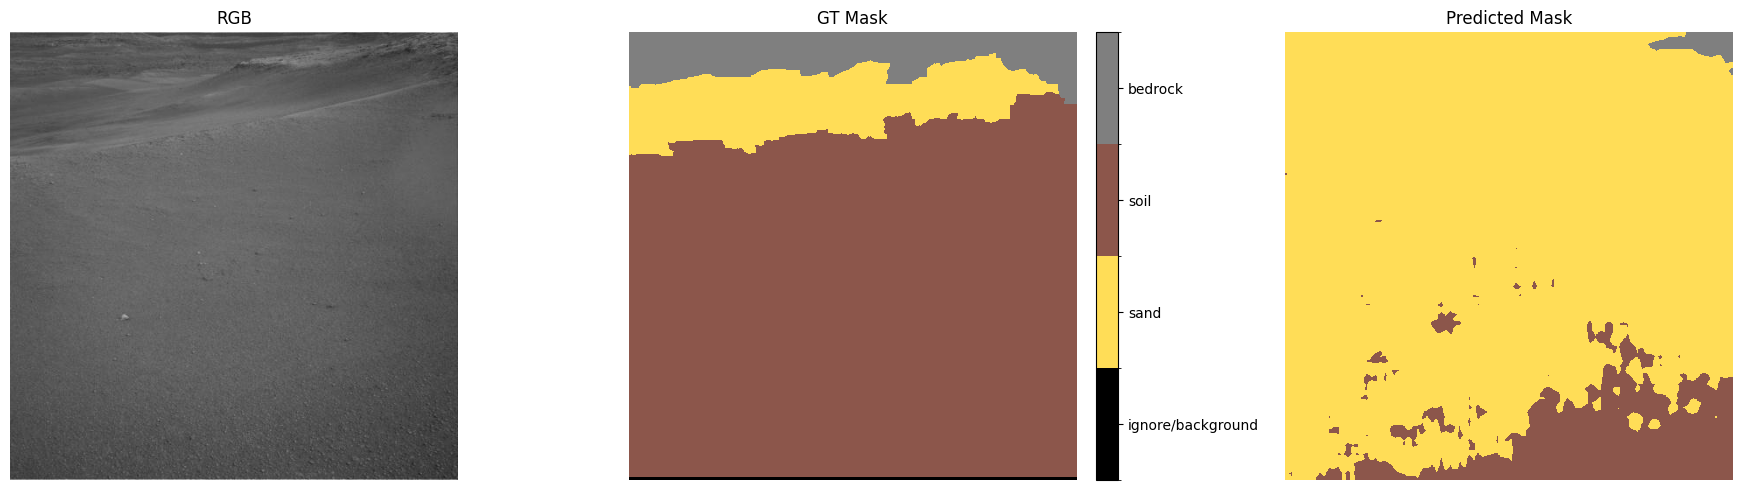


[5] 0900.png | idx=126 | error_rate=0.6582 | unique IDs (GT): [0, 2, 3]


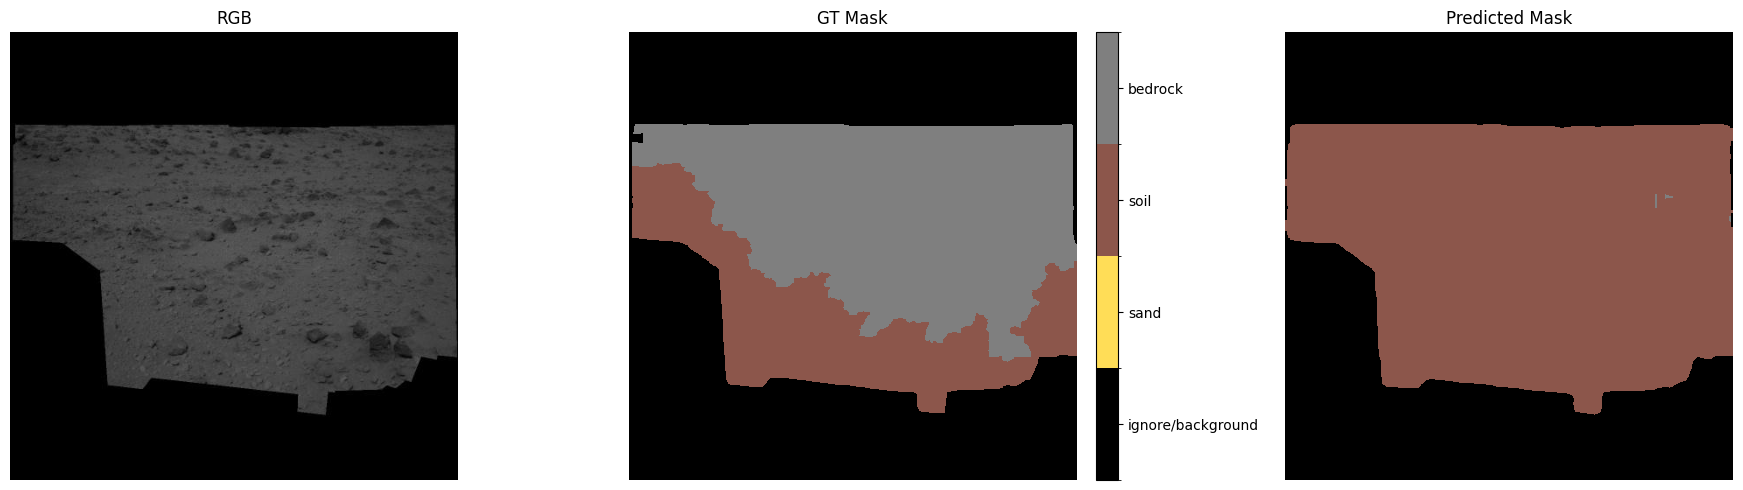


[6] 0803.png | idx=29 | error_rate=0.5719 | unique IDs (GT): [0, 1, 2]


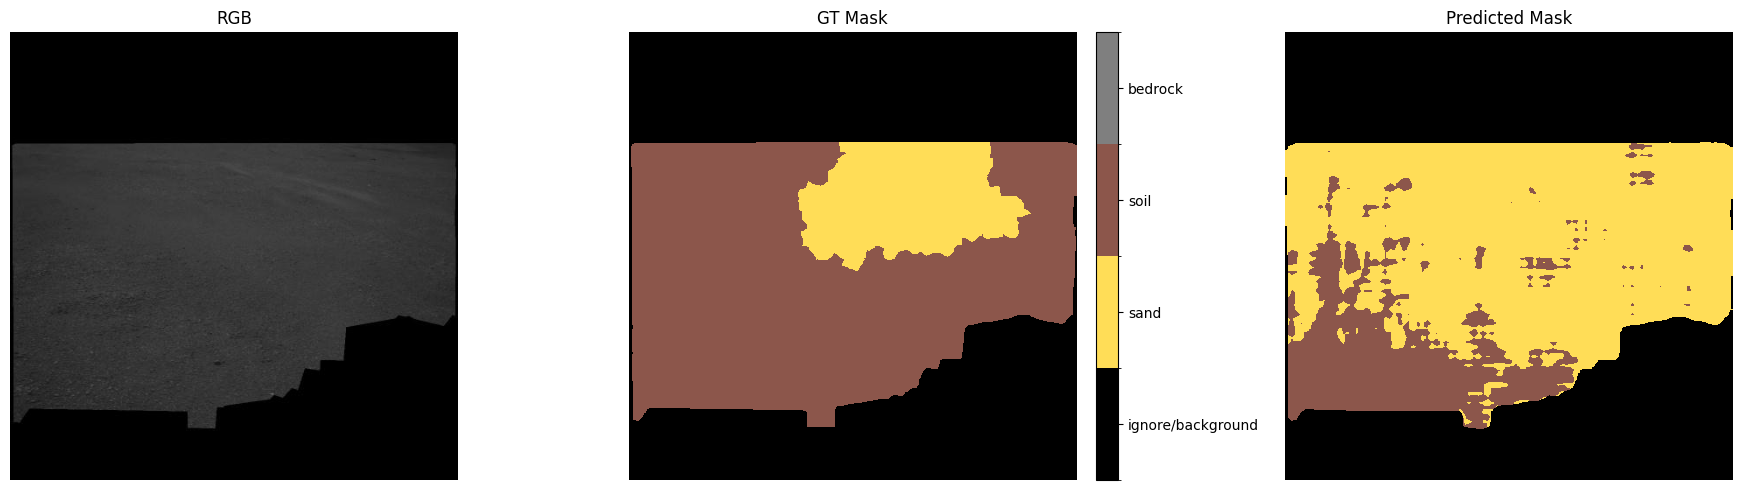


[7] 0846.png | idx=72 | error_rate=0.4539 | unique IDs (GT): [0, 1, 2, 3]


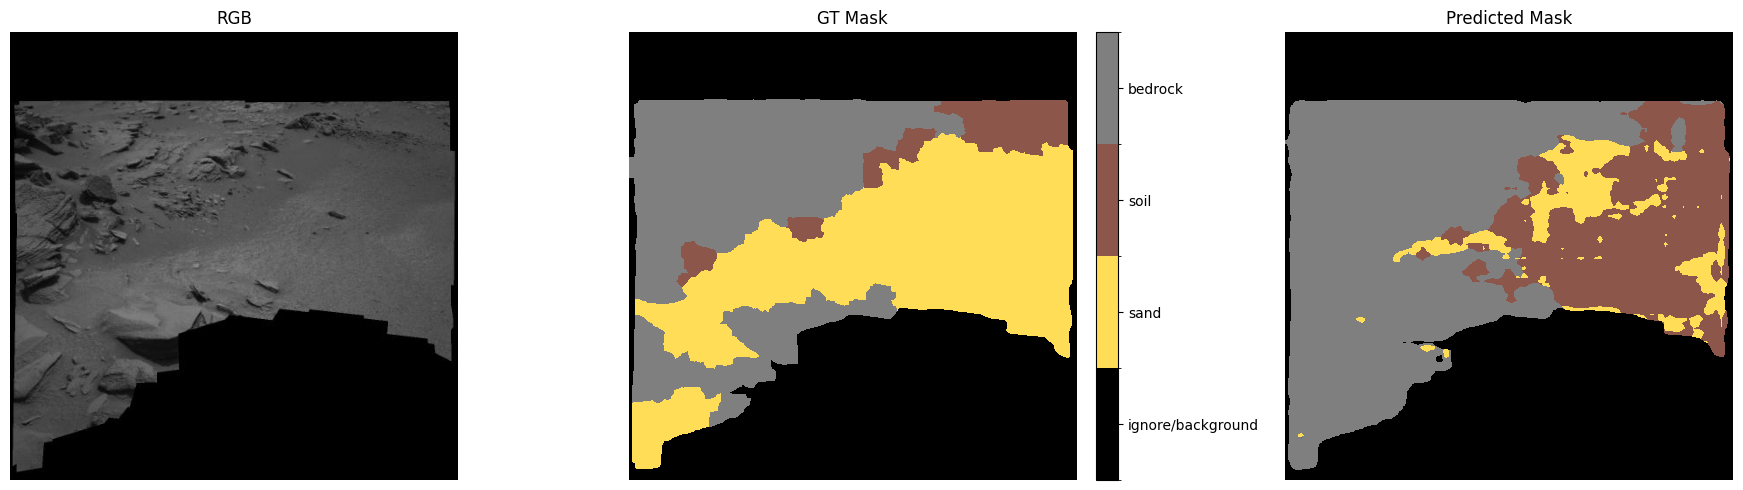


[8] 0901.png | idx=127 | error_rate=0.4462 | unique IDs (GT): [0, 2, 3]


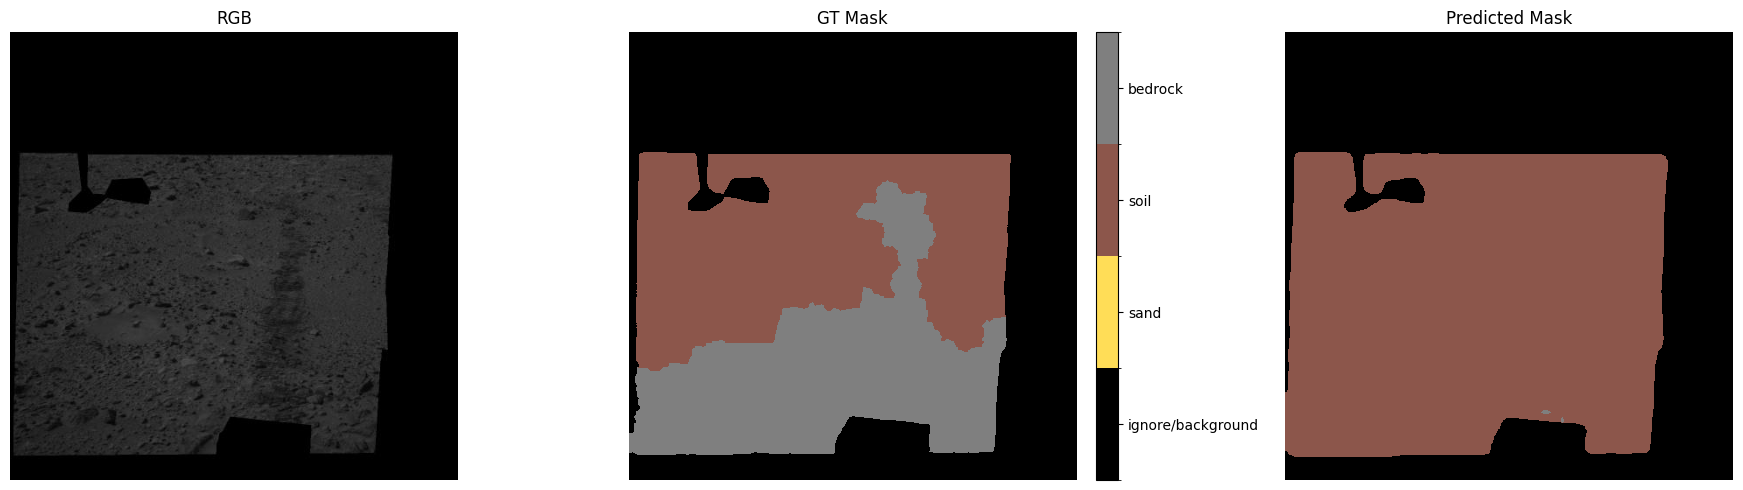


[9] 0881.png | idx=107 | error_rate=0.4108 | unique IDs (GT): [0, 2, 3]


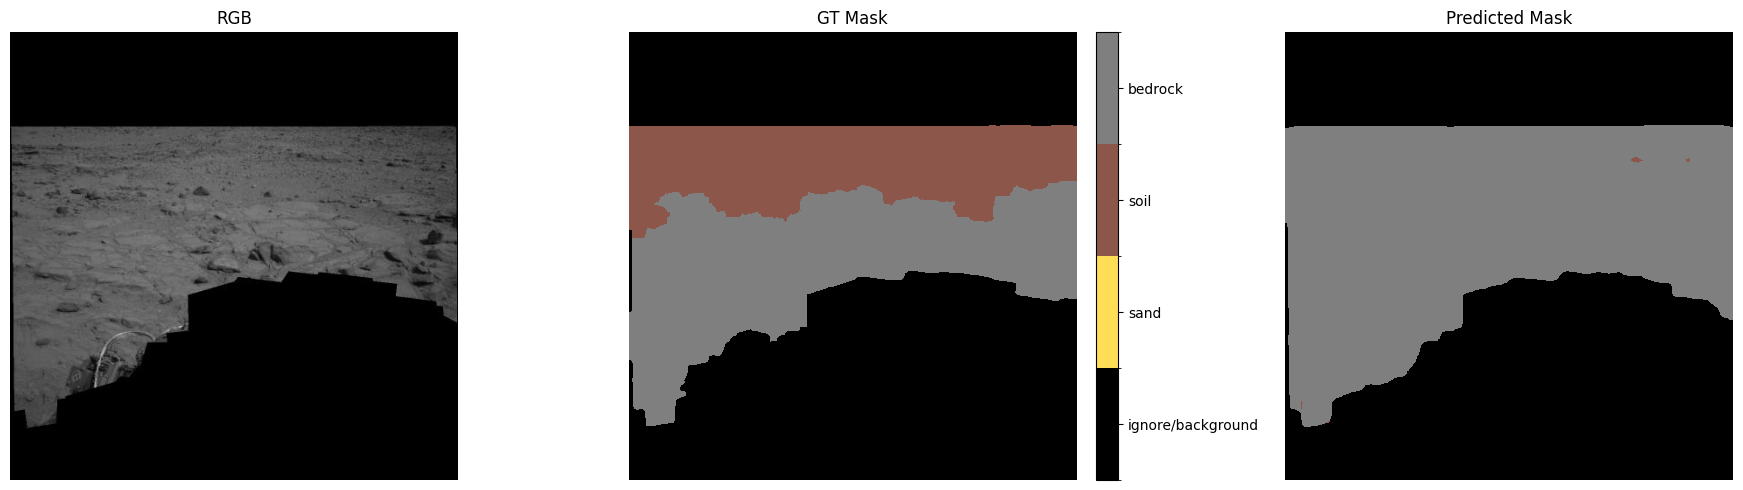


[10] 0821.png | idx=47 | error_rate=0.0004 | unique IDs (GT): [0, 2]


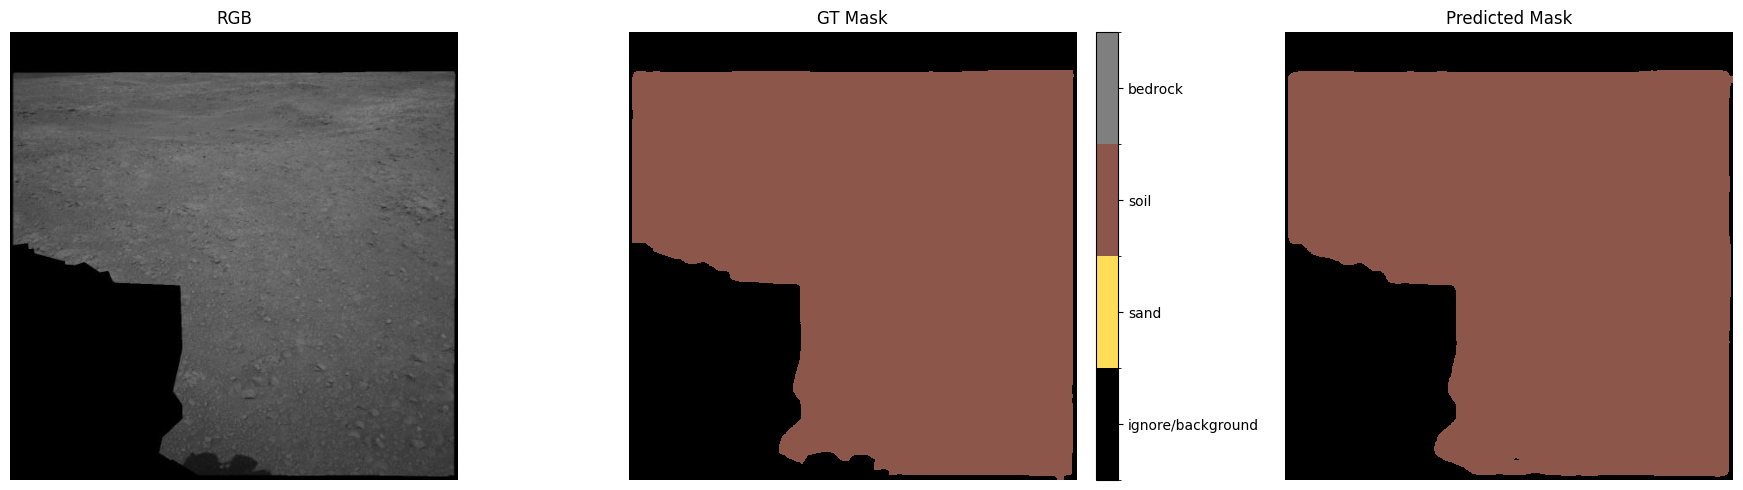


[11] 0886.png | idx=112 | error_rate=0.0003 | unique IDs (GT): [0, 2]


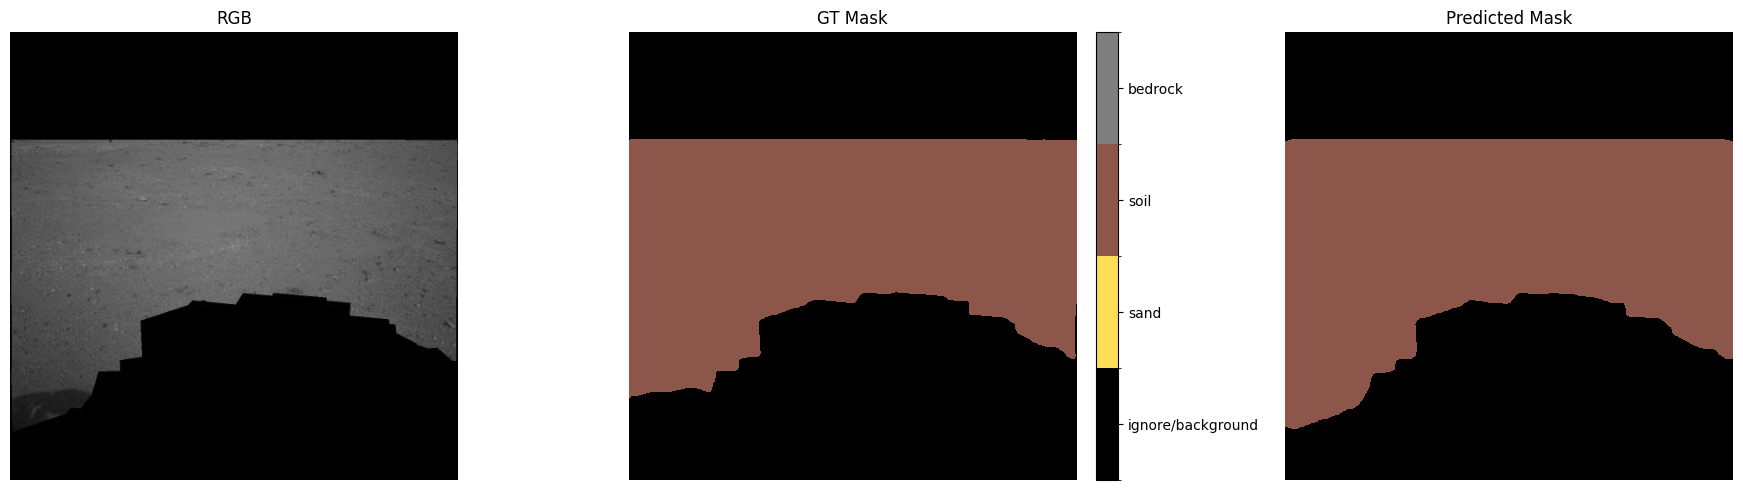


[12] 0888.png | idx=114 | error_rate=0.0003 | unique IDs (GT): [0, 3]


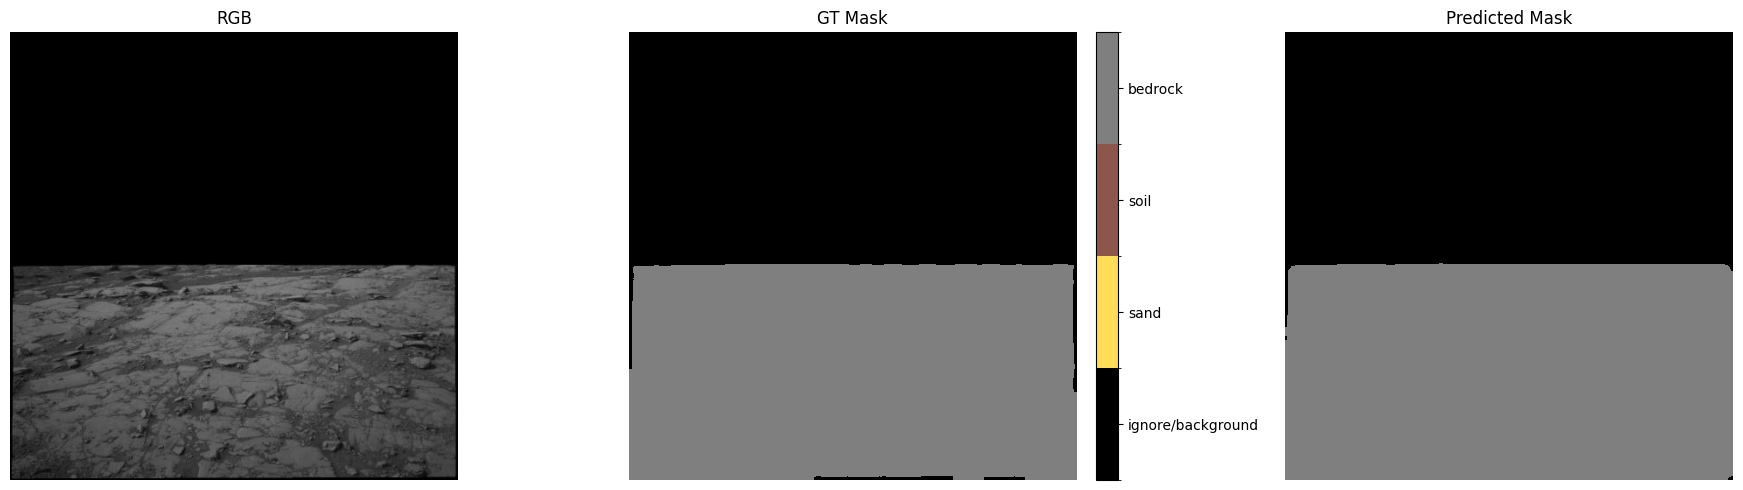


[13] 0811.png | idx=37 | error_rate=0.0002 | unique IDs (GT): [0, 1]


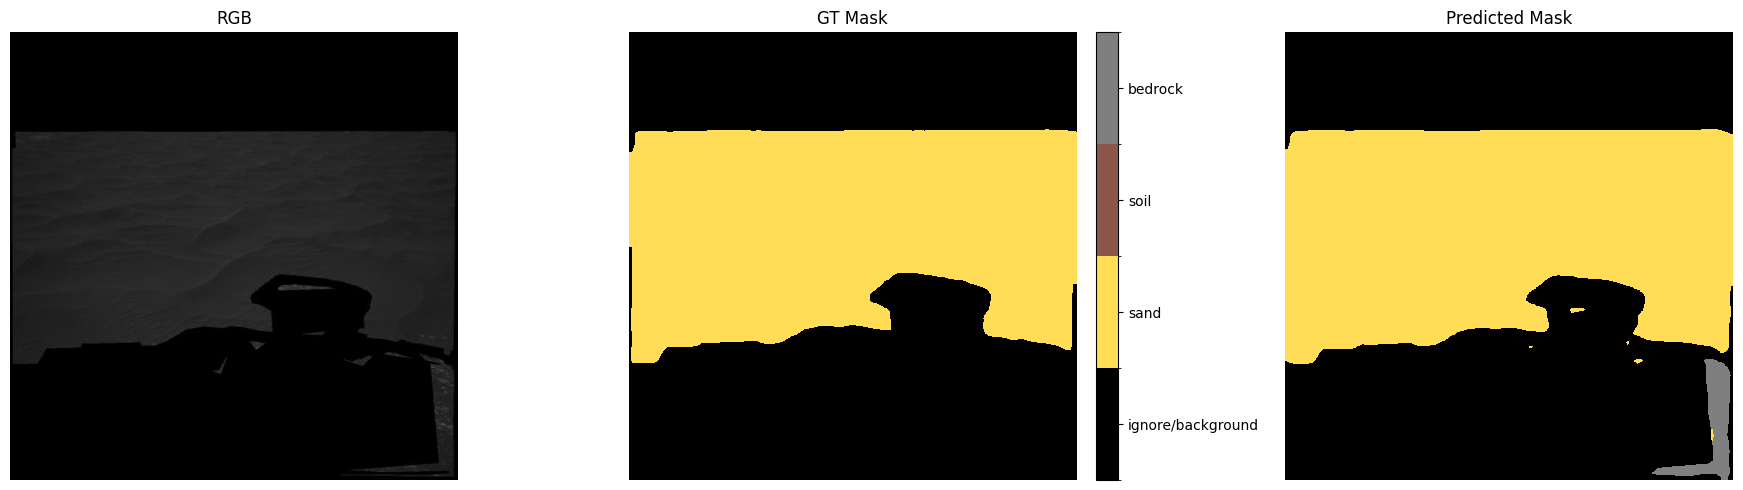


[14] 0845.png | idx=71 | error_rate=0.0002 | unique IDs (GT): [0, 3]


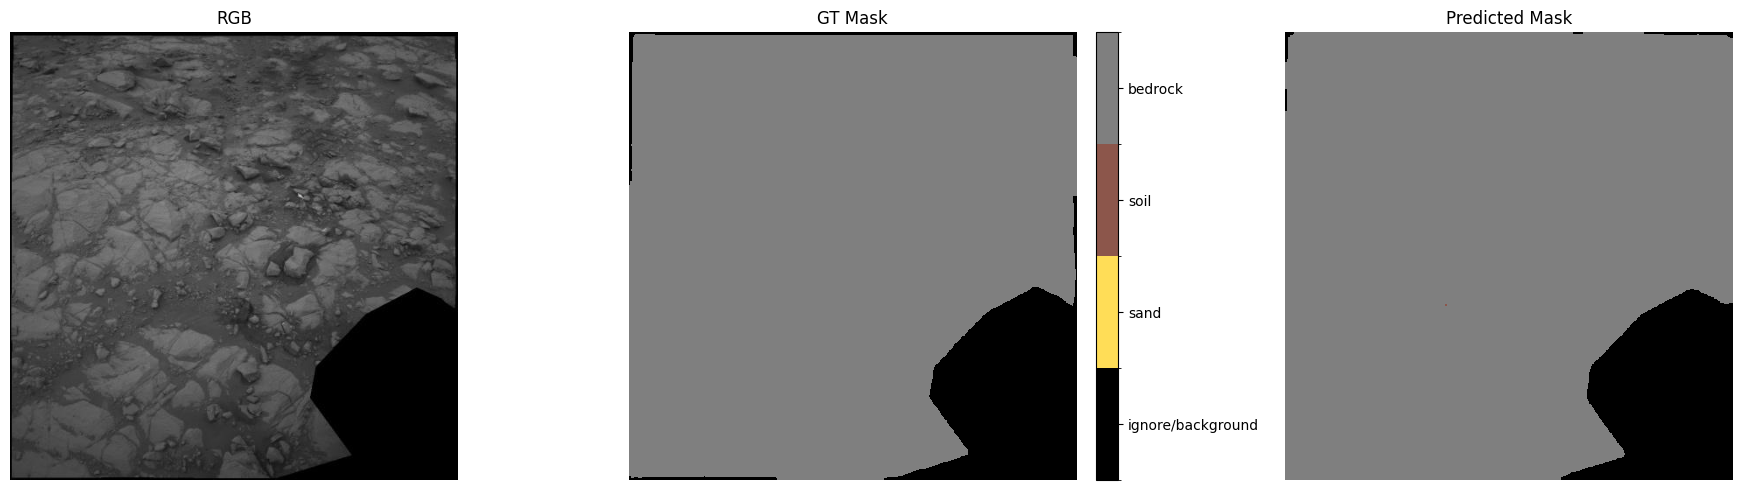


[15] 0838.png | idx=64 | error_rate=0.0001 | unique IDs (GT): [0, 1]


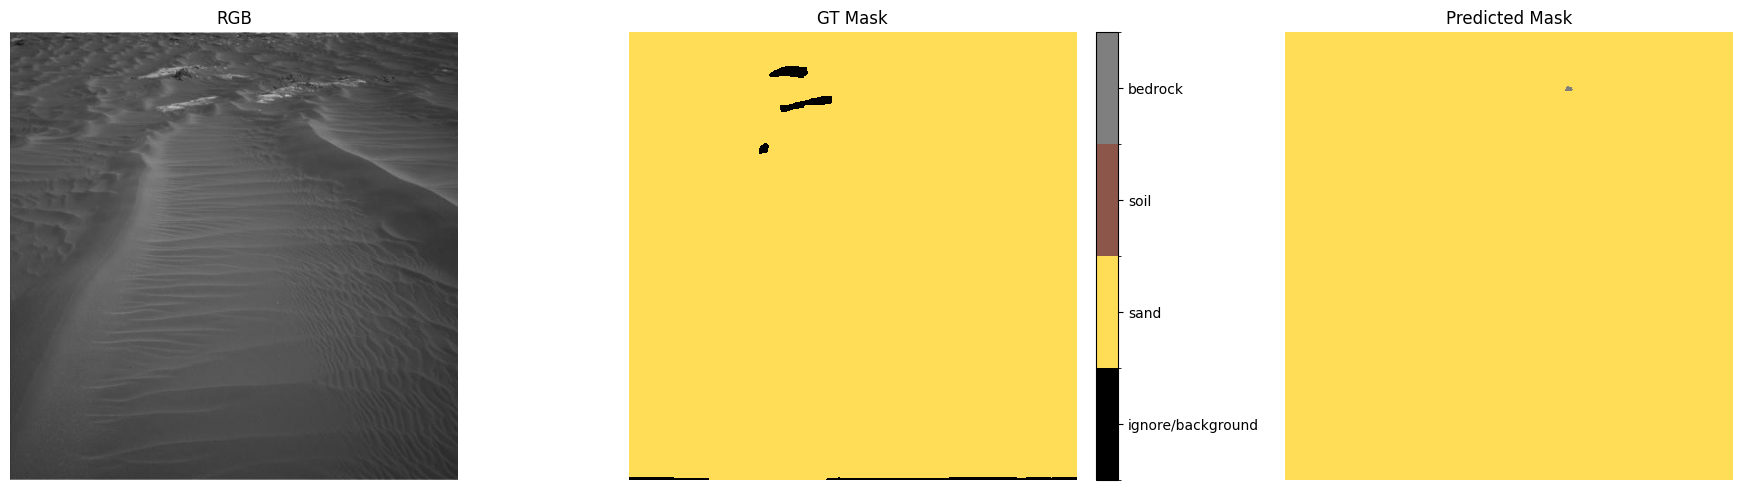


[16] 0836.png | idx=62 | error_rate=0.0001 | unique IDs (GT): [0, 1]


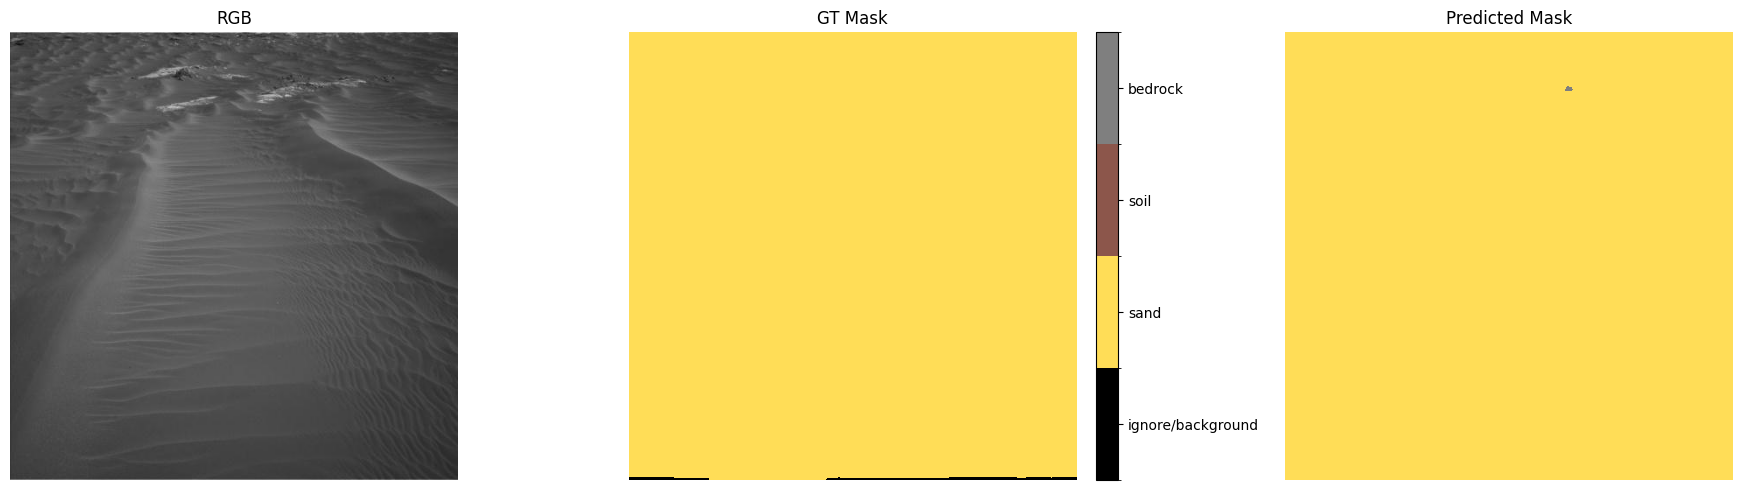


[17] 0876.png | idx=102 | error_rate=0.0001 | unique IDs (GT): [0, 2]


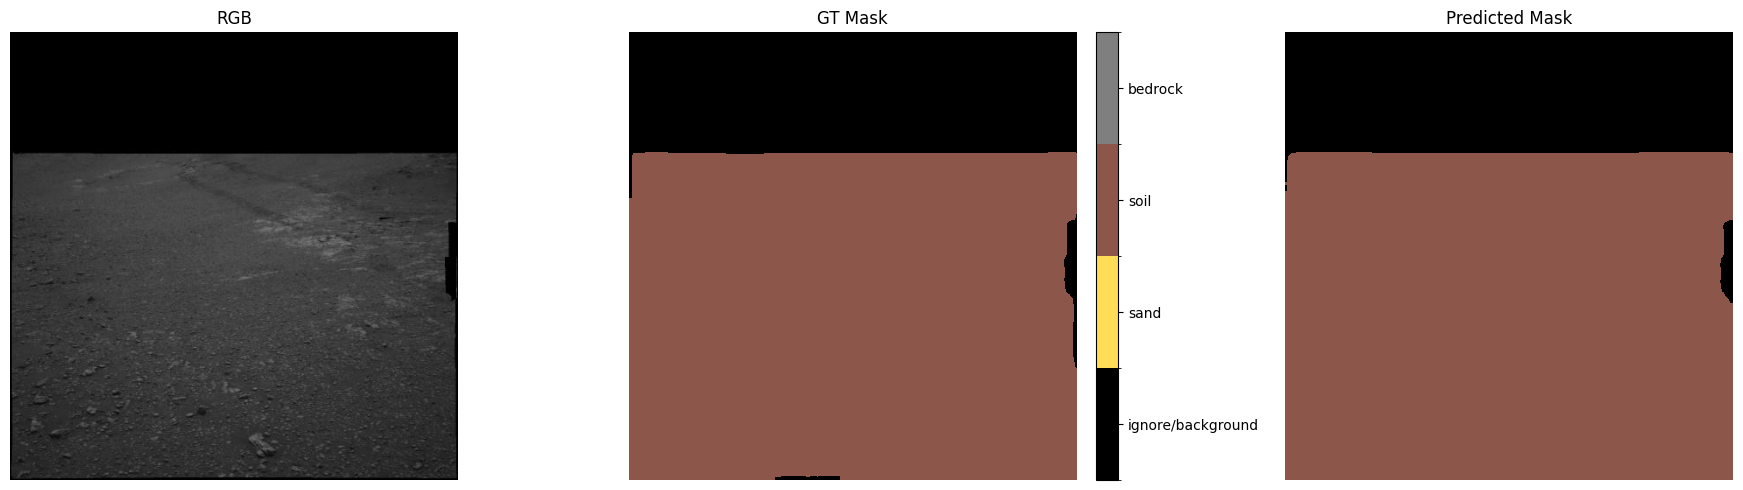


[18] 0873.png | idx=99 | error_rate=0.0000 | unique IDs (GT): [0, 2]


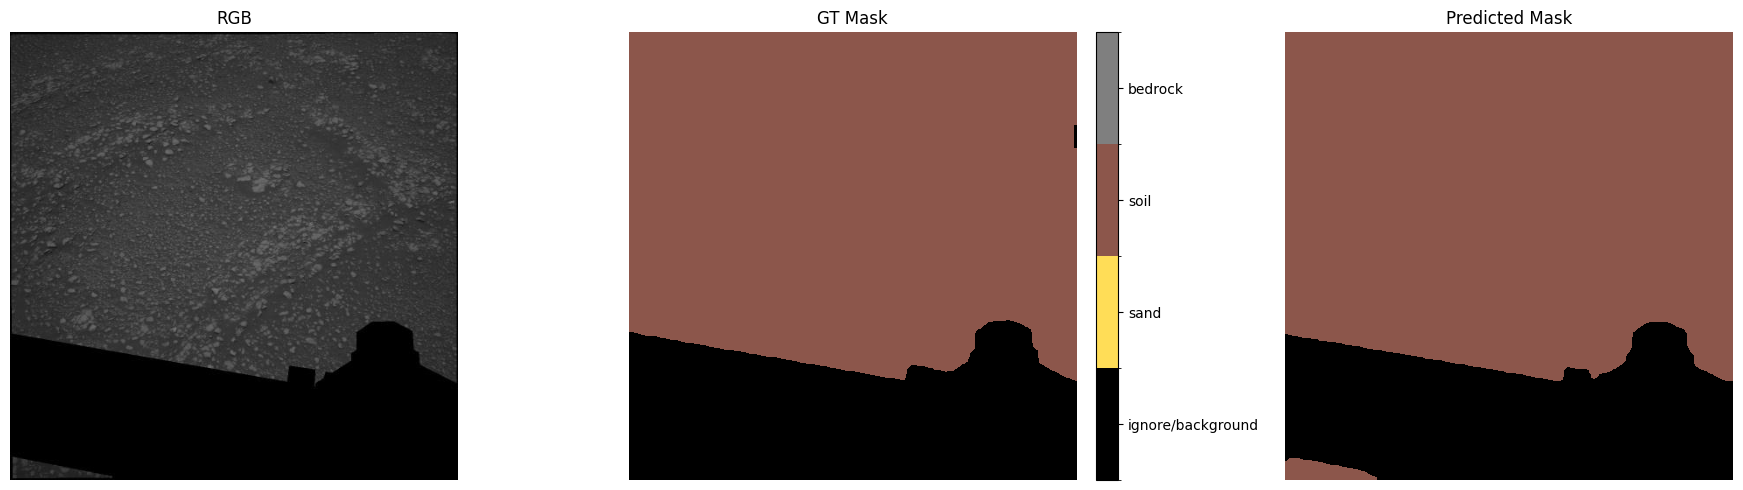


[19] 0809.png | idx=35 | error_rate=0.0000 | unique IDs (GT): [0, 2]


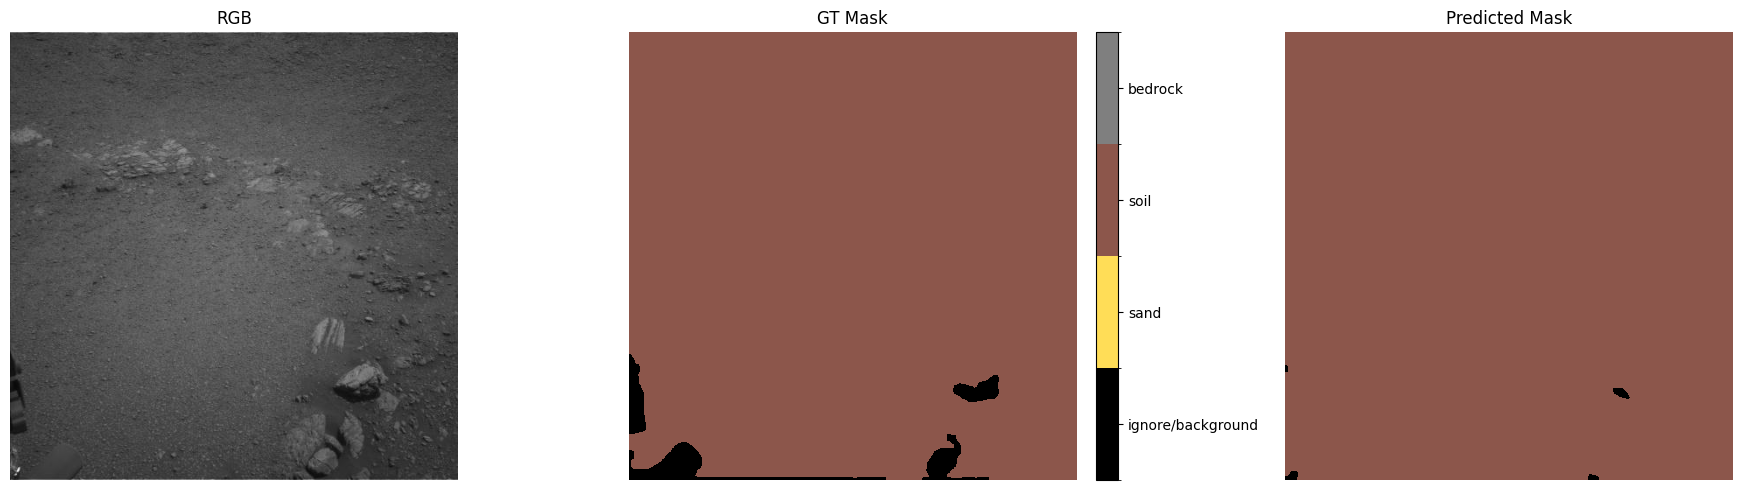

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch # Import torch for model inference

def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

def load_mask(path):
    return np.array(Image.open(path))  # keep raw IDs

def build_fixed_cmap_for_ids_0_to_4():
    colors = [
        "#000000",  # 0 ignore/background
        "#ffdd57",  # 1 sand
        "#8c564b",  # 2 soil
        "#7f7f7f",  # 3 bedrock
    ]
    cmap = ListedColormap(colors)
    boundaries = np.arange(-0.5, 4.5, 1.0) # Adjusted for 4 classes (0 to 3)
    norm = BoundaryNorm(boundaries, cmap.N)
    return cmap, norm

def inspect_images_from_records(images_dir, masks_dir, records_to_visualize, class_names_all=None):
    cmap, norm = build_fixed_cmap_for_ids_0_to_4()

    # Ensure class_names_all matches the 4 classes (0-3) using NUM_CLASSES_WITH_IGNORE
    if class_names_all is None or len(class_names_all) != NUM_CLASSES_WITH_IGNORE:
        class_names_all = [ID_TO_NAME[i] for i in range(NUM_CLASSES_WITH_IGNORE)]

    ticks = list(range(len(class_names_all)))  # [0,1,2,3]

    model.eval() # Ensure model is in evaluation mode
    with torch.no_grad():
        for i, record in enumerate(records_to_visualize):
            error_rate, global_idx, name = record # Extract name from the record
            img_path = os.path.join(images_dir, name)
            mask_path = os.path.join(masks_dir, name)

            rgb = load_rgb(img_path)
            gt_mask = load_mask(mask_path)

            # Prepare image for model inference
            image_for_model = Image.open(img_path).convert("RGB")
            # Assuming val_transform and DEVICE are globally available as in previous cells
            transformed_image = val_transform(image=np.array(image_for_model))["image"].unsqueeze(0).to(DEVICE)

            # Get model prediction
            model_output = model(transformed_image)["out"]
            predicted_mask = torch.argmax(model_output, dim=1).squeeze(0).cpu().numpy()

            uniq_gt = np.unique(gt_mask)
            print(f"\n[{i}] {name} | idx={global_idx} | error_rate={error_rate:.4f} | unique IDs (GT):", uniq_gt.tolist())

            plt.figure(figsize=(18,5)) # Adjusted figure size for 3 plots

            plt.subplot(1,3,1)
            plt.imshow(rgb)
            plt.title("RGB")
            plt.axis("off")

            plt.subplot(1,3,2)
            im_gt = plt.imshow(gt_mask, cmap=cmap, norm=norm, interpolation="nearest")
            plt.title("GT Mask")
            plt.axis("off")

            plt.subplot(1,3,3)
            im_pred = plt.imshow(predicted_mask, cmap=cmap, norm=norm, interpolation="nearest")
            plt.title("Predicted Mask")
            plt.axis("off")

            cbar = plt.colorbar(im_gt, fraction=0.046, pad=0.04)
            cbar.set_ticks(ticks)
            cbar.set_ticklabels(class_names_all)

            plt.tight_layout()
            plt.show()

inspect_images_from_records(IMAGES_DIR, MASKS_DIR, records_to_visualize=worst_records_final, class_names_all=CLASS_NAMES_ALL)